# Spam Email Classification using Machine Learning
Developed by Aishee Mukherjee and Debopriya Das
## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Scikit-learn
- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Naive Bayes
- Logistic Regression
- Support Vector Machine (SVM)
- Matplotlib
- Seaborn
- WordCloud
- Pickle

## Project Objective

The goal of this project is to build a Machine Learning model that can classify emails/messages as spam or non-spam using Natural Language Processing techniques.

**Importing libraries**

In [1]:
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Information

Dataset Used: SMS Spam Collection Dataset

Features:
- label → spam or ham
- message → actual text message

Total Records: 5572

**Upload Dataset ( SMS Spam Collection Dataset. )**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


**Load Dataset**

In [3]:
# Load dataset
df = pd.read_csv(
    'SMSSpamCollection',
    sep='\t',
    names=['label', 'message']
)

# Show first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Exploratory Data Analysis (EDA)**

In [19]:
df.isnull().sum()

,0
label,0
message,0
clean_message,0


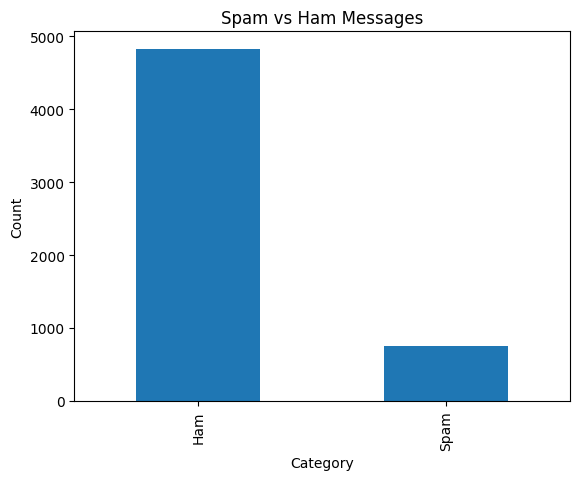

(5572, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   label          5572 non-null   int64 
 1   message        5572 non-null   object
 2   clean_message  5572 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


,count
label,
0,4825
1,747


In [22]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.xticks([0,1], ['Ham', 'Spam'])
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Spam vs Ham Messages")

plt.show()
print(df.shape)

df.info()

df['label'].value_counts()

**WordCloud Visualization**

In [23]:
!pip install wordcloud

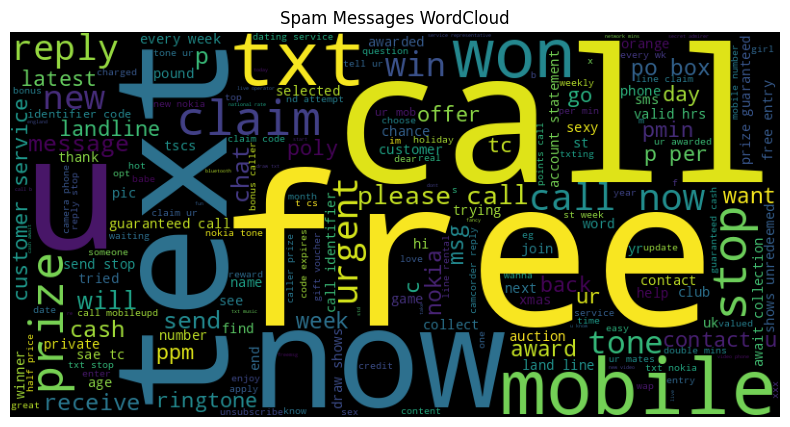

In [24]:
from wordcloud import WordCloud

spam_words = ' '.join(
    df[df['label'] == 1]['clean_message']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()

**Convert Label to Numbers**

In [6]:
# Convert labels
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**Cleaning Text Data**

In [7]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = text.strip()

    return text

In [8]:
df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


**Splitting Input and Output**

In [9]:
X = df['clean_message']
y = df['label']

**Convert Text into Numbers Using TF-IDF**

In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

**Split Training and Testing Data**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training the ML Model

**Naive Bayes**

In [35]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.957847533632287


**Logistic Regression**

In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9623318385650225


**SVM**

In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9847533632286996


## Model Comparison

Three Machine Learning algorithms were compared for spam email classification:
- Naive Bayes
- Logistic Regression
- Support Vector Machine (SVM)

The model with the highest accuracy performed best for text classification.

In [36]:
models = [
    'Naive Bayes',
    'Logistic Regression',
    'SVM'
]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison

,Model,Accuracy
0,Naive Bayes,0.957848
1,Logistic Regression,0.962332
2,SVM,0.984753


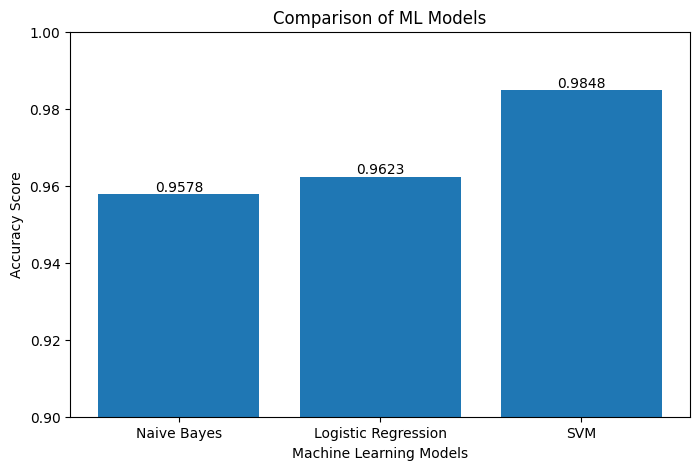

In [37]:
plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy Score")

plt.title("Comparison of ML Models")

plt.ylim(0.9, 1.0)

# Add values on bars
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 4),
        ha='center',
        va='bottom'
    )

plt.show()

**Heatmap Confusion Matrix**

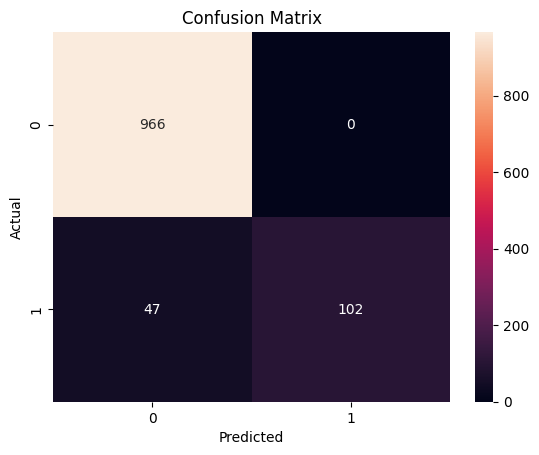

In [29]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**User Input Prediction Section**

In [30]:
message = input("Enter a message: ")

message_clean = clean_text(message)

message_vector = vectorizer.transform([message_clean])

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Non-Spam Message")

Enter a message: Hey do we have a class tomorrow?
Non-Spam Message


In [33]:
message = input("Enter a message: ")

message_clean = clean_text(message)

message_vector = vectorizer.transform([message_clean])

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Non-Spam Message")

Enter a message: Congratulations! You won a free iPhone. Click now!
Spam Message


**Save the models**

In [40]:
import pickle

# Naive Bayes
pickle.dump(nb_model,
            open('naive_bayes_model.pkl', 'wb'))

# Logistic Regression
pickle.dump(lr_model,
            open('logistic_regression_model.pkl', 'wb'))

# SVM
pickle.dump(svm_model,
            open('svm_model.pkl', 'wb'))

# TF-IDF Vectorizer
pickle.dump(vectorizer,
            open('vectorizer.pkl', 'wb'))

## Conclusion

The project successfully classified spam and non-spam messages using NLP and Machine Learning techniques. Among the tested models, SVM achieved the highest accuracy.